Shape: (6362620, 11)

Primeiras linhas:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Dtypes:
step                int64
type                  str
amou

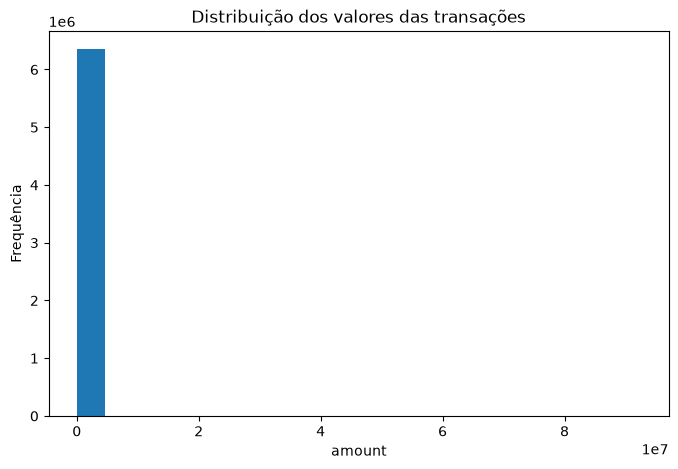

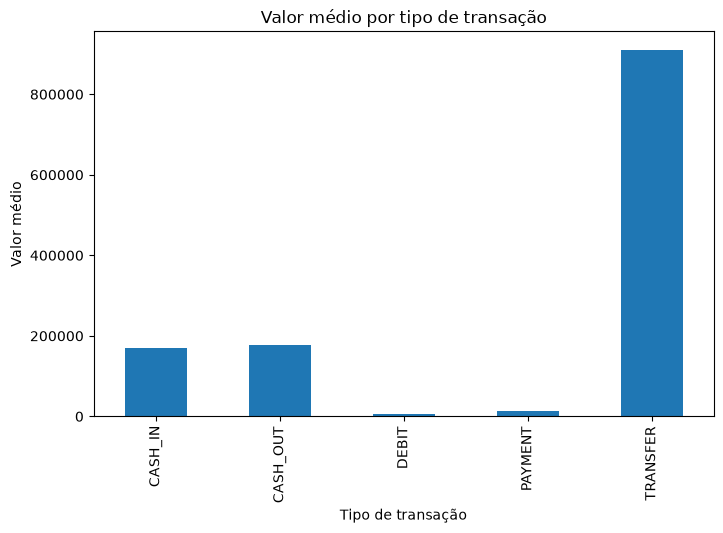

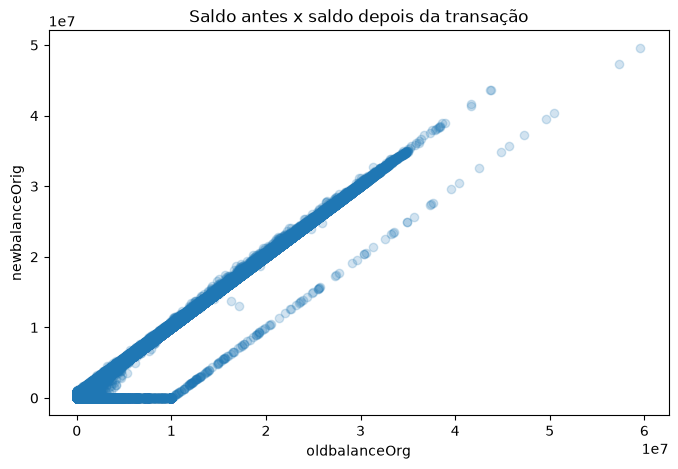

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) Carregar o dataset
# ============================================================

df = pd.read_csv(r'C:\Users\luigi\Downloads\Fraud.csv')

# ============================================================
# 2) Estrutura
# ============================================================

print("Shape:", df.shape)

print("\nPrimeiras linhas:")
print(df.head())

print("\nDtypes:")
print(df.dtypes)

# ============================================================
# 3) Valores ausentes
# ============================================================

print("\nNaN por coluna:")
print(df.isna().sum())

# ============================================================
# 4) Estatísticas numéricas
# ============================================================

print("\nEstatísticas numéricas:")
print(df.select_dtypes(include="number").describe())

# ============================================================
# 5) Estatísticas categóricas
# ============================================================

cat_cols = df.select_dtypes(exclude="number").columns.tolist()

if len(cat_cols) > 0:
    for c in cat_cols:
        print(f"\nValue counts: {c}")
        print(df[c].value_counts().head(10))

# ============================================================
# 6) Gráfico 1 - Histograma
# ============================================================

plt.figure(figsize=(8,5))
plt.hist(df["amount"], bins=20)
plt.title("Distribuição dos valores das transações")
plt.xlabel("amount")
plt.ylabel("Frequência")
plt.show()

# ============================================================
# 7) Gráfico 2 - Barras
# ============================================================

plt.figure(figsize=(8,5))
df.groupby("type")["amount"].mean().plot(kind="bar")
plt.title("Valor médio por tipo de transação")
plt.xlabel("Tipo de transação")
plt.ylabel("Valor médio")
plt.show()

# ============================================================
# 8) Gráfico 3 - Scatter
# ============================================================

plt.figure(figsize=(8,5))
plt.scatter(
    df["oldbalanceOrg"],
    df["newbalanceOrig"],
    alpha=0.2
)
plt.title("Saldo antes x saldo depois da transação")
plt.xlabel("oldbalanceOrg")
plt.ylabel("newbalanceOrig")
plt.show()